# 00. Exploring Broden

Network Dissection scores a unit by comparing its activations with human labeled visual concepts. **Broden is the dataset that provides those labels.** It gives, for each image, the annotations that exist. It does not label every concept in every image.

Paper: [local PDF](Network_dissection.pdf), Sec. 2.1 and Table 1. Sec. 2.2 explains which images enter each IoU score.

## The series

Bau et al., *Network Dissection: Quantifying Interpretability of Deep Visual Representations*, CVPR 2017. One idea per notebook.

| # | Notebook | Idea | Comparison |
|---|---|---|---|
| 00 | broden_exploration | the concept dataset | file format, categories, label encoding |
| 01 | units_and_hooks | a unit and its activation map | vertical vs horizontal edge unit, hand made vs learned |
| 02 | concepts_as_masks | concepts as pixel sets | pixel labels vs image labels |
| 03 | threshold | turning a map into a mask | fixed threshold vs per unit quantile |
| 04 | upsampling | matching resolutions | plain resize vs receptive field anchoring |

## Setup

`BRODEN` is relative, so the kernel must be started from the repository root.

In [1]:
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATA = Path("data")
BRODEN = DATA / "broden1_227"
plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 9})

## Getting the data

The archive is the Broden 1.0 export at 227 × 227 (about 975 MB). The original server is offline, so the URL points to the Wayback Machine copy, which can be slow.

The download is skipped when `index.csv` already exists. A new download goes to `.zip.part` and is renamed only once complete, so an interrupted download is never mistaken for a finished one. Extraction creates `data/broden1_227/`.

In [2]:
URL = "https://web.archive.org/web/20240418040425id_/http://netdissect.csail.mit.edu/data/broden1_227.zip"
if not (BRODEN / "index.csv").exists():
    DATA.mkdir(exist_ok=True)
    zip_path = DATA / "broden1_227.zip"
    if not zip_path.exists():
        partial_path = zip_path.with_suffix(".zip.part")
        urllib.request.urlretrieve(URL, partial_path)
        partial_path.replace(zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(DATA)
print(sorted(p.name for p in BRODEN.iterdir()))

['README.txt', 'c_color.csv', 'c_material.csv', 'c_object.csv', 'c_part.csv', 'c_scene.csv', 'c_texture.csv', 'category.csv', 'images', 'index.csv', 'label.csv', 'syns.txt']


## The files

* `index.csv`: one row per image, listing its annotations.
* `label.csv`: one row per **global concept ID** (1,197 here). ID 0 means unlabeled and has no row.
* `category.csv`: the six annotation categories.
* `c_<category>.csv`: the concepts of one category. `number` is the global ID stored in the PNGs, `code` is a category local ID. The two are not interchangeable.

Category columns are read as strings because a field can be a PNG path, a whole image ID such as `"960"`, or several entries separated by `;`. An empty field becomes `NaN`, but the string `"0"` also means unlabeled.

`ih`/`iw` are the image height and width, `sh`/`sw` the segmentation height and width, and `split` is the train/val assignment of the export (both are used here). We expect 63,305 images and 1,197 concepts.

In [3]:
CATEGORIES = ["object", "part", "material", "color", "scene", "texture"]
index = pd.read_csv(BRODEN / "index.csv", dtype={c: str for c in CATEGORIES})
label = pd.read_csv(BRODEN / "label.csv")
category = pd.read_csv(BRODEN / "category.csv")
print(len(index), "images", len(label), "concepts")
index.sample(4, random_state=0)

63305 images 1197 concepts


,image,split,ih,iw,sh,sw,color,object,part,material,scene,texture
44612,opensurfaces/10933.jpg,val,227,227,113,113,opensurfaces/10933_color.png,NaN,NaN,opensurfaces/10933_material.png,NaN,NaN
18965,opensurfaces/24722.jpg,train,227,227,113,113,opensurfaces/24722_color.png,NaN,NaN,opensurfaces/24722_material.png,NaN,NaN
40357,ade20k/ADE_train_00020070.jpg,train,227,227,113,113,ade20k/ADE_train_00020070_color.png,ade20k/ADE_train_00020070_object.png,NaN,NaN,960,NaN
45584,ade20k/ADE_train_00003153.jpg,val,227,227,113,113,ade20k/ADE_train_00003153_color.png,ade20k/ADE_train_00003153_object.png,ade20k/ADE_train_00003153_part_1.png,NaN,995,NaN


In [4]:
label.head(8)

,number,name,category,frequency,coverage,syns
0,1,black-c,color(62358),62358,11135.320474,NaN
1,2,grey-c,color(62310),62310,12712.843129,NaN
2,3,white-c,color(62054),62054,5778.038204,NaN
3,4,brown-c,color(61583),61583,14549.652454,NaN
4,5,green-c,color(61508),61508,5049.989735,NaN
5,6,pink-c,color(60755),60755,1478.518582,NaN
6,7,purple-c,color(59516),59516,865.041519,NaN
7,8,blue-c,color(57825),57825,4899.174121,NaN


`number` is the concept ID and `name` its readable label. Suffixes such as `-c` (color) and `-s` (scene) keep names from colliding across categories.

`category` lists every category a concept belongs to, with a count per category. `wall` is `object(15553);part(29)`, and its global `frequency` 15,582 is the sum of the two. Per category frequencies are in `c_<category>.csv`.

`coverage` is measured in whole image units: a concept covering 20% of each of 10 images has coverage 2. It is not a pixel count. These statistics come from the [dataset builder](https://github.com/CSAILVision/NetDissect/blob/master/src/joinseg.py) and were computed before resizing, so an exact recount on the final PNGs can differ slightly.

A **category** is an annotation type (object, part, ...), a **concept** is a label (wall, leg, ...). One concept can belong to several categories.

## Where the images come from

Broden merges five datasets: ADE20K, Pascal-Context, Pascal-Part, OpenSurfaces and DTD. The two Pascal datasets share the same images, so there are only four folder prefixes.

The prefix of each image path gives its source. `has` marks, for every image and category, whether at least one real annotation entry exists: empty fields and the whole image label `0` do not count. For pixel categories this only checks that a file is listed, not that the mask has positive pixels.

A zero in the object column for DTD means **no object annotations**, not that the photos contain no objects.

In [5]:
index["source"] = index.image.str.split("/").str[0]


def has_label_entry(field):
    if pd.isna(field):
        return False
    # A numeric 0 is unlabeled, paths identify pixel annotation files.
    return any(token and (not token.isdigit() or int(token) > 0)
               for token in field.split(";"))


has = index[CATEGORIES].apply(lambda column: column.map(has_label_entry))
by_source = has.groupby(index.source).sum()
by_source.insert(0, "images", index.source.value_counts())
by_source

,images,object,part,material,color,scene,texture
source,,,,,,,
ade20k,22210,22210,11560,0,22210,17746,0
dtd,5640,0,0,0,5640,0,5640
opensurfaces,25352,0,0,25352,25352,0,0
pascal,10103,10103,10103,0,10103,0,0


ADE20K supplies objects, parts and scenes, Pascal supplies objects and parts, OpenSurfaces supplies materials and DTD supplies textures. Colors are generated for every image.

ADE20K has 17,746 images with a positive scene label. Another 1,987 have a scene field equal to `0`, which a plain `.notna()` check would wrongly count.

The category columns overlap, so they do not add up to the dataset size.

## Table 1 of the paper

The first two columns are copied from Table 1. The next two are recomputed from `c_<category>.csv`: the number of concepts and their mean frequency, rounded like the paper.

In [6]:
paper = pd.DataFrame({"classes (paper)": [584, 234, 32, 11, 468, 47],
                      "avg sample (paper)": [491, 854, 1703, 59250, 38, 140]}, index=CATEGORIES)
for c in CATEGORIES:
    t = pd.read_csv(BRODEN / f"c_{c}.csv")
    t = t[t.number > 0]
    paper.loc[c, "classes"] = len(t)
    paper.loc[c, "avg sample"] = round(t.frequency.mean())
paper = paper.astype(int)
paper["avg difference (%)"] = (100 * (paper["avg sample"] / paper["avg sample (paper)"] - 1)).round(1)
paper

,classes (paper),avg sample (paper),classes,avg sample,avg difference (%)
object,584,491,584,464,-5.5
part,234,854,234,566,-33.7
material,32,1703,32,1703,0.0
color,11,59250,11,59252,0.0
scene,468,38,468,38,0.0
texture,47,140,47,141,0.7


All six class counts match Table 1. The averages match for material, color, scene and texture, but objects are 5.5% lower (464 vs 491) and parts 33.7% lower (566 vs 854).

The export is dated 2017-04-24 (`README.txt`). Neither the paper nor the README explains the part gap. A different export or counting rule is plausible but unverified.

The class counts sum to **1,376** while `label.csv` has **1,197** IDs, because some concepts sit in several categories. `windowpane`, for instance, is both an object and a part.

## How a pixel label is stored

Pixel labels are PNG files whose channels **encode integers**, not colors:

$$\mathrm{ID}(y,x) = R(y,x) + 256\,G(y,x).$$

Red holds the low byte, green the high byte, blue is unused. ID 0 means unlabeled. For example $R=63$, $G=1$ gives ID $319$.

The array is cast to `int64` before multiplying, since `256 * G` overflows in `uint8`. The result holds one global concept ID per pixel. We take the first image that has both object and part entries, and only its first object file.

In [7]:
def decode(path):
    with Image.open(BRODEN / "images" / path) as png:
        rgb = np.asarray(png.convert("RGB"), dtype=np.int64)
    return rgb[..., 0] + 256 * rgb[..., 1]


name = dict(zip(label.number, label.name))
row = index[has["object"] & has["part"]].iloc[0]
obj = decode(row.object.split(";")[0])
print("image", row.image, "segmentation size", obj.shape)
print("concepts in the object map:", [name.get(v, "unlabeled") for v in np.unique(obj)])
max_id = int(obj.max())
print(f"largest concept ID: {max_id} = {max_id % 256} + 256 * {max_id // 256}")

image ade20k/ADE_train_00006107.jpg segmentation size (113, 113)
concepts in the object map: ['unlabeled', 'wall', 'floor', 'table', 'chair', 'heater']
largest concept ID: 319 = 63 + 256 * 1


The object map contains wall, floor, table, chair and heater, plus unlabeled pixels. The largest ID, 319 (heater), splits into $63 + 256 \times 1$.

Every row of this export has **227 × 227 images and 113 × 113 segmentations**, about half resolution. Activation maps will have to be brought onto this grid (notebook 04). Activations are interpolated bilinearly. A label map, if it ever needs resizing, must use nearest neighbor so that no invented IDs appear.

## One example per category

Objects, parts, materials and colors are pixel annotations. Scenes and textures are whole image labels: a positive label counts as covering the entire image. A field can hold several `;` separated entries, especially for parts and textures.

For each category we scan a fixed random sample of annotated images until we find a non empty entry. A whole image ID gives an all `True` mask. For a PNG we keep the most frequent non zero ID of that map and build its mask with `seg == v`. `overlay` dims every pixel outside the mask to 25% brightness.

This shows one concept from one entry. The full mask of a concept in an image is the union over all its entries.

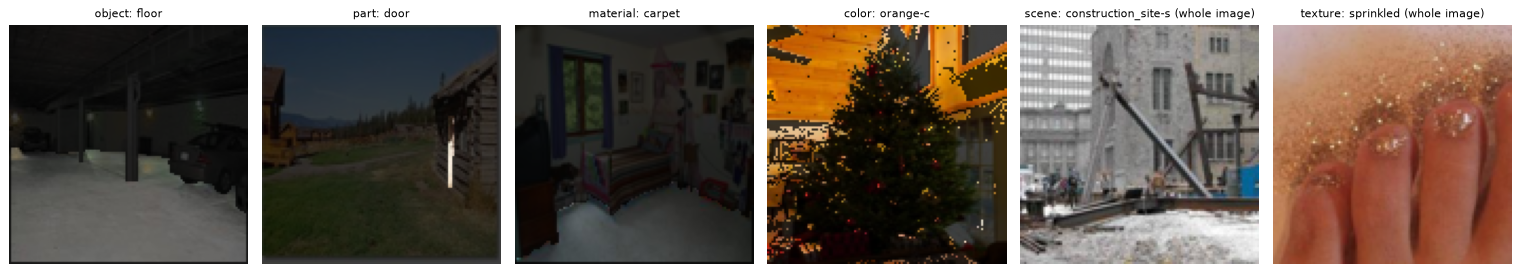

In [8]:
def overlay(ax, img_path, mask, title):
    with Image.open(BRODEN / "images" / img_path) as photo:
        img = np.asarray(photo.convert("RGB").resize(mask.shape[::-1])) / 255
    ax.imshow(img * np.where(mask[..., None], 1.0, 0.25))
    ax.set_title(title)
    ax.axis("off")


fig, axes = plt.subplots(1, 6, figsize=(17, 3.2))
for ax, cat in zip(axes, CATEGORIES):
    example = None
    candidates = index[has[cat]].sample(min(50, int(has[cat].sum())), random_state=4)
    for _, r in candidates.iterrows():
        for entry in r[cat].split(";"):
            if not entry:
                continue
            if entry.isdigit():
                v = int(entry)
                if v == 0:
                    continue
                mask = np.ones((int(r.sh), int(r.sw)), dtype=bool)
                title = f"{cat}: {name[v]} (whole image)"
            else:
                seg = decode(entry)
                if not (seg > 0).any():
                    continue
                values, counts = np.unique(seg[seg > 0], return_counts=True)
                v = values[counts.argmax()]
                mask, title = seg == v, f"{cat}: {name[v]}"
            example = (r.image, mask, title)
            break
        if example is not None:
            break
    if example is None:
        raise ValueError(f"No positive {cat} annotation in the sampled images")
    overlay(ax, *example)
plt.tight_layout()
plt.show()

## Several labels on one pixel

Categories do not compete: the same pixel can be an object, a part and a color at once, since these describe different properties of the region.

We pick an image with object, part and color entries, decode the first file of each, and read all three maps at one labeled part pixel (the middle one of `np.argwhere(part > 0)`). The maps share the same 113 × 113 grid, so the same `(y, x)` refers to the same place.

In [9]:
r = index[has["object"] & has["part"] & has["color"]].iloc[3]
maps = {c: decode(r[c].split(";")[0]) for c in ("object", "part", "color")}
part_pixels = np.argwhere(maps["part"] > 0)
y, x = part_pixels[len(part_pixels) // 2]
print(f"pixel ({y}, {x}) of {r.image}:")
for c, m in maps.items():
    print(f"  {c:7s} {name.get(m[y, x], 'unlabeled')}")

pixel (39, 78) of ade20k/ADE_train_00018550.jpg:
  object  building
  part    windowpane
  color   black-c


## A long tail

The paper keeps concepts with at least 10 image samples, and the export's README adds a minimum coverage of 0.5. The frequency filter applies to the global count of a concept, not to each of its categories.

Below, object and texture concepts are sorted by frequency and plotted on a log scale. The x axis is the rank, not the ID. Objects range from wall (15,553) down to 1, while textures stay between 120 and 316. The two panels have different y scales.

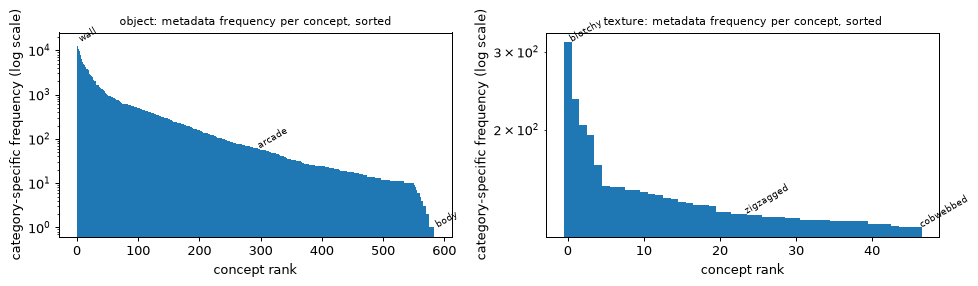

smallest global concept frequency: 10
smallest category-specific frequency: {'object': 1, 'part': 1, 'material': 6, 'color': 50369, 'scene': 10, 'texture': 120}


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, cat in zip(axes, ("object", "texture")):
    t = pd.read_csv(BRODEN / f"c_{cat}.csv")
    t = t[t.number > 0].sort_values("frequency", ascending=False)
    ax.bar(range(len(t)), t.frequency, width=1.0)
    ax.set_yscale("log")
    ax.set_title(f"{cat}: metadata frequency per concept, sorted")
    ax.set_xlabel("concept rank")
    ax.set_ylabel("category-specific frequency (log scale)")
    for i in (0, len(t) // 2, len(t) - 1):
        ax.annotate(t.name.iloc[i], (i, t.frequency.iloc[i]), fontsize=7, rotation=30)
plt.tight_layout()
plt.show()
print("smallest global concept frequency:", label.frequency[label.number > 0].min())
print("smallest category-specific frequency:", {
    c: int(pd.read_csv(BRODEN / f"c_{c}.csv").frequency.min()) for c in CATEGORIES
})

## Not every image has every category

A DTD image has a texture label but no object annotations. When scoring a unit against **dog**, that image should not count against the unit, since we do not know whether a dog is there. An object annotated image without a dog label does count, and any mask the unit fires there is a false positive.

Sec. 2.2 therefore sums over the images that have at least one label in the concept's category:

$$\operatorname{IoU}_{k,c} =
\frac{\sum_{x\in D_{\mathrm{category}(c)}} |M_k(x)\cap L_c(x)|}
{\sum_{x\in D_{\mathrm{category}(c)}} |M_k(x)\cup L_c(x)|}$$

$M_k$ is the unit's binary mask, $L_c$ the concept's label mask and $D_{\mathrm{category}(c)}$ the eligible images. Pixel counts are summed over the dataset before dividing. This is not a mean of per image IoUs.

The table below gives the size of each eligible subset. The subsets overlap, so the shares do not sum to 1. For pixel categories the count is of listed files. The scoring code must still check that the decoded masks contain a positive label.

In [11]:
counts = has.sum().rename("images with category annotation entries")
counts.to_frame().assign(share=lambda d: (d.iloc[:, 0] / len(index)).round(2))

,images with category annotation entries,share
object,32313,0.51
part,21663,0.34
material,25352,0.40
color,63305,1.00
scene,17746,0.28
texture,5640,0.09


## Takeaways

* 63,305 images and 1,197 concept IDs, from five datasets stored under four folder prefixes.
* Categories overlap in images and in concepts: 1,376 category memberships for 1,197 concepts.
* Objects, parts, materials and colors are pixel masks, scenes and textures are whole image labels. A field can hold several `;` separated entries.
* PNG labels decode as `R + 256 * G`. The global `number` differs from the per category `code`. Images are 227 × 227, segmentations 113 × 113.
* An empty field or label `0` means unlabeled, not absent. Category availability decides which images enter a concept's IoU.
* Table 1 class counts are reproduced. The part frequency average is not (566 vs 854), for an unknown reason.
* The minimum global frequency is 10, but a concept can appear fewer times within one category.

Next, notebook 01 introduces units and their activation maps.